In [1]:
import Gurobi
using JuMP
using Plots
using StructArrays
using DataFrames

┌ Warning: attempting to remove probably stale pidfile
│   path = C:\Users\juliu\.julia\compiled\v1.11\Gurobi\do9v6_gTSwt.ji.pidfile
└ @ FileWatching.Pidfile C:\Users\juliu\AppData\Local\Programs\Julia-1.11.5\share\julia\stdlib\v1.11\FileWatching\src\pidfile.jl:249
┌ Warning: attempting to remove probably stale pidfile
│   path = "C:\\Users\\juliu\\.julia\\compiled\\v1.11\\MathOptInterface\\tyub8_gTSwt.ji.pidfile"
└ @ FileWatching.Pidfile C:\Users\juliu\AppData\Local\Programs\Julia-1.11.5\share\julia\stdlib\v1.11\FileWatching\src\pidfile.jl:249


In [2]:
struct Slot
    Tag::String
    Beginn::Int
    Ende::Int
end

In [3]:
struct Person
    Name::String
    Wunschslots::Vector{Slot}
    Ausweichslots::Vector{Slot}
    Blockslots::Vector
    zusammenhängend::Bool
end

In [5]:
personen = Vector{Person}()

push!(personen, Person("Julius",
    [
        Slot("Mittwoch", 14, 18),
        Slot("Mittwoch", 10, 12),
    ],
    [
        Slot("Montag", 10, 12),
        Slot("Dienstag", 12, 16),
        Slot("Donnerstag", 10, 12),
    ],
    [
        Slot("Montag", 8, 10),
        Slot("Montag", 12, 18),
        Slot("Dienstag", 8, 12),
        Slot("Dienstag", 16, 18),
        Slot("Mittwoch", 8, 10),
        Slot("Mittwoch", 12, 14),
        Slot("Donnerstag", 8, 10),
        Slot("Donnerstag", 12, 18),
        Slot("Freitag", 8, 18)
    ],
    true))

push!(personen, Person("Charlotte",
    [
        Slot("Dienstag", 10, 18),
    ],
    [
        Slot("Montag", 14, 16),
        Slot("Mittwoch", 14, 16),
    ],
    [
        Slot("Montag", 8, 14),
        Slot("Dienstag", 8, 14),
        Slot("Mittwoch", 8, 14),
        Slot("Donnerstag", 8, 16),
        Slot("Freitag", 8, 16)
    ],
    true))

push!(personen, Person("Jonas",
    [
        Slot("Montag", 8, 10),
        Slot("Montag", 12, 16),
        Slot("Dienstag", 8, 12),
        Slot("Mittwoch", 8, 12),
        Slot("Donnerstag", 8, 18),
    ],
    [
        Slot("Dienstag", 14, 18),
        Slot("Mittwoch", 14, 16),
    ],
    [
        Slot("Montag", 10, 12),
        Slot("Dienstag", 12, 14),
        Slot("Dienstag", 16, 18),
        Slot("Mittwoch", 12, 16),
        Slot("Donnerstag", 10, 12),
        Slot("Freitag", 8, 18),
    ],
    true))

push!(personen, Person("Arwed",
    [
        Slot("Montag", 10, 14),
    ],
    [
        Slot("Dienstag", 12, 16),
        Slot("Mittwoch", 10, 14)
    ],
    [
        Slot("Montag", 8, 10),
        Slot("Montag", 14, 16),
        Slot("Dienstag", 8, 10),
        Slot("Dienstag", 16, 18),
        Slot("Mittwoch", 8, 10),
        Slot("Mittwoch", 14, 16),
        Slot("Donnerstag", 8, 18),
        Slot("Freitag", 8, 18)
    ],
    true))

push!(personen, Person("Dominik",
    [
        Slot("Montag", 12, 16),
        Slot("Dienstag", 10, 14),
        Slot("Mittwoch", 12, 16),
    ],
    [
        Slot("Montag", 10, 12),
        Slot("Dienstag", 14, 18),
        Slot("Mittwoch", 14, 16),
        Slot("Donnerstag", 10, 12),
    ],
    [
        Slot("Mittwoch", 10, 14),
    ],
    true))


5-element Vector{Person}:
 Person("Julius", Slot[Slot("Mittwoch", 14, 18), Slot("Mittwoch", 10, 12)], Slot[Slot("Montag", 10, 12), Slot("Dienstag", 12, 16), Slot("Donnerstag", 10, 12)], Slot[Slot("Montag", 8, 10), Slot("Montag", 12, 18), Slot("Dienstag", 8, 12), Slot("Dienstag", 16, 18), Slot("Mittwoch", 8, 10), Slot("Mittwoch", 12, 14), Slot("Donnerstag", 8, 10), Slot("Donnerstag", 12, 18), Slot("Freitag", 8, 18)], true)
 Person("Charlotte", Slot[Slot("Dienstag", 10, 18)], Slot[Slot("Montag", 14, 16), Slot("Mittwoch", 14, 16)], Slot[Slot("Montag", 8, 14), Slot("Dienstag", 8, 14), Slot("Mittwoch", 8, 14), Slot("Donnerstag", 8, 16), Slot("Freitag", 8, 16)], true)
 Person("Jonas", Slot[Slot("Montag", 8, 10), Slot("Montag", 12, 16), Slot("Dienstag", 8, 12), Slot("Mittwoch", 8, 12), Slot("Donnerstag", 8, 18)], Slot[Slot("Dienstag", 14, 18), Slot("Mittwoch", 14, 16)], Slot[Slot("Montag", 10, 12), Slot("Dienstag", 12, 14), Slot("Dienstag", 16, 18), Slot("Mittwoch", 12, 16), Slot("Donnerstag"

In [6]:
vorlesung = Slot("Mittwoch", 16, 18)
uebung = Slot("Montag", 16, 18)

Slot("Montag", 16, 18)

In [35]:
function process_personen(personen::Vector{Person})
    processed_personen = Vector{Person}()
    for p in personen
        person = Person(p.Name, Vector{Slot}(), Vector{Slot}(), Vector{Slot}(), p.zusammenhängend)
        for wunsch in p.Wunschslots
            for i in range(start = wunsch.Beginn, stop = wunsch.Ende - 2, step = 2)
                push!(person.Wunschslots, Slot(wunsch.Tag, i, i + 2))
            end
        end
        for ausweich in p.Ausweichslots
            for i in range(start = ausweich.Beginn, stop = ausweich.Ende - 2, step = 2)
                push!(person.Ausweichslots, Slot(ausweich.Tag, i, i + 2))
            end
        end
        for block in p.Blockslots
            if block == "alles andere"
                # Handle the case where the block is "alles andere"
                for tag in ["Montag", "Dienstag", "Mittwoch", "Donnerstag", "Freitag"]
                    for i in range(start = 8, stop = 20-2, step = 2)
                        if Slot(tag, i, i + 2) ∉ person.Wunschslots && Slot(tag, i, i + 2) ∉ person.Ausweichslots
                            push!(person.Blockslots, Slot(tag, i, i + 2))
                        end
                    end
                end
            else
                for i in range(start = block.Beginn, stop = block.Ende -2 , step = 2)
                    push!(person.Blockslots, Slot(block.Tag, i, i + 2))
                end
            end
        end
        push!(processed_personen, person)
    end
    return StructArray(processed_personen)
end

process_personen (generic function with 1 method)

In [36]:
processed_personen = process_personen(personen);

In [37]:
alle_slots = Vector{Slot}()
for tag in ["Montag", "Dienstag", "Mittwoch", "Donnerstag", "Freitag"]
    for i in range(start = 8, stop = 20-2, step = 2)
        push!(alle_slots, Slot(tag, i, i + 2))
    end
end

In [ ]:
function create_and_solve_model(processed_personen::StructArray{Person}, alle_slots::Vector{Slot})
    model = JuMP.Model(Gurobi.Optimizer)
    set_string_names_on_creation(model, false)

    @variable(model, x[processed_personen.Name, alle_slots], Bin)

    @constraint(model, [s in alle_slots], sum(x[p.Name, s] for p in processed_personen) <= 1)

    @constraint(model, [p in processed_personen], sum(x[p.Name, s] for s in alle_slots) == 2)

    @constraint(model, [p in processed_personen], sum(x[p.Name, s] for s in p.Blockslots) == 0)

    @constraint(model, [s in [vorlesung, uebung]],
        sum(x[p.Name, s] for p in processed_personen) == 0)


    @variable(model, Nutzen[processed_personen.Name])

    @constraint(model, [p in processed_personen],
        Nutzen[p.Name] == 3 * sum(x[p.Name, s] for s in p.Wunschslots) + sum(x[p.Name, s] for s in p.Ausweichslots))

    @variable(model, mean_nutzen)

    @constraint(model, mean_nutzen == sum(Nutzen[p.Name] for p in processed_personen) / length(processed_personen))

    # for p in processed_personen ist noch nicht implementiert
    #     if p.zusammenhänged
    #         @constraint(model,
    #             sum(x[p.Name, s1] for s1 ))

    # @objective(model, Min, sum((Nutzen[p.Name] - mean_nutzen) ^ 2 for p in processed_personen) - sum(Nutzen[p.Name] for p in processed_personen))
    @objective(model, Max, sum(Nutzen[p.Name] for p in processed_personen))


    set_optimizer_attribute(model, "OutputFlag", 0)
    set_optimizer_attribute(model, "TimeLimit", 1*60)

    optimize!(model)

    return JuMP.value.(x)
end

create_and_solve_model (generic function with 1 method)

In [73]:
solved_x = create_and_solve_model(processed_personen, alle_slots);

Set parameter Username
Set parameter LicenseID to value 2591745
Academic license - for non-commercial use only - expires 2025-11-26


ErrorException: At d:\Privates\Programming\Finished\Tutoriumsplanung\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X12sZmlsZQ==.jl:26: `@constraint(model, [$(Expr(:parameters, :(p.zusammenhängend && (alle_slots[i]).tag == (alle_slots[i + 1]).tag))), p in processed_personen, i in 1:length(alle_slots) - 1], x[p.Name, alle_slots[i]] - x[p.Name, alle_slots[i + 1]] == 0)`: unexpected error parsing condition: p.zusammenhängend && (alle_slots[i]).tag == (alle_slots[i + 1]).tag

In [63]:
processed_solution = Dict{String, Vector{Slot}}()

for person in processed_personen
    processed_solution[person.Name] = Vector{Slot}()
    for slot in alle_slots
        if solved_x[person.Name, slot] == 1
            processed_solution[person.Name] = push!(processed_solution[person.Name], Slot(slot.Tag, slot.Beginn, slot.Ende))
        end
    end
end

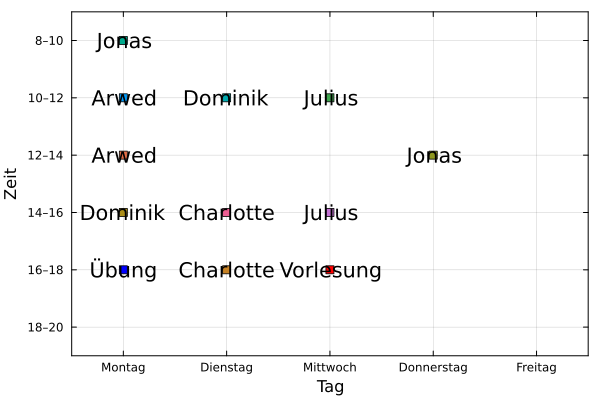

In [64]:
tage = ["Montag", "Dienstag", "Mittwoch", "Donnerstag", "Freitag"]
times = 8:2:18  # Startzeiten: 8–10, 10–12, ..., 18–20

# Mapping Tag -> X-Achse
tag_to_x = Dict(tag => i for (i, tag) in enumerate(tage))

# Mapping Zeit -> Y-Achse
time_to_y = Dict(t => length(times) - i + 1 for (i, t) in enumerate(times))  # neu: 8 → oben


# Vorbereitung für Plot
scatter();  # leeres Plotfenster
for (person, slots) in processed_solution
    for s in slots
        x = tag_to_x[s.Tag]
        y = time_to_y[s.Beginn]
        scatter!([x], [y], markershape=:rect, label="", annotate=(x, y, person))
    end
end

# Vorlesung plotten (z. B. als rotes Quadrat)
scatter!([tag_to_x[vorlesung.Tag]], [time_to_y[vorlesung.Beginn]],
    markershape=:rect, color=:red, label="", annotate=(tag_to_x[vorlesung.Tag], time_to_y[vorlesung.Beginn], "Vorlesung"))

# Übung plotten (z. B. als blaues Quadrat)
scatter!([tag_to_x[uebung.Tag]], [time_to_y[uebung.Beginn]],
    markershape=:rect, color=:blue, label="", annotate=(tag_to_x[uebung.Tag], time_to_y[uebung.Beginn], "Übung"))


# Achsen konfigurieren
plot!(xlim=(0.5, length(tage)+0.5), ylim=(0.5, length(times)+0.5),
    xticks=(1:length(tage), tage),
    yticks=(1:length(times), reverse(string.(times) .* "–" .* string.(times .+ 2))),
    xlabel="Tag", ylabel="Zeit", legend=false, framestyle=:box)